# Chapter 130 — Direction Vectors

> **Prerequisites:** Scalar Multiplication (ch126), Vector Length (ch128), Vector Representation (ch124)
> **You will learn:**
> - How to extract direction from a vector (normalization)
> - Standard basis vectors as canonical directions
> - How direction vectors parametrize lines in any dimension
> - Applications: ray tracing, velocity decomposition, steering

> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Every non-zero vector encodes two pieces of information: **magnitude** and **direction**. We have already studied magnitude (the norm). A **direction vector** is a vector that encodes *only* direction — magnitude 1.

More generally, any non-zero vector defines a direction: "the direction of **v**" means the unit vector $\hat{\mathbf{v}} = \mathbf{v} / \|\mathbf{v}\|$.

Direction vectors are also called **unit vectors**. They lie on the unit sphere (L2 unit ball).

**Line through a point:** Given a point P and a direction **d**, the line through P in direction **d** is the set of all points $P + t\mathbf{d}$ for $t \in \mathbb{R}$. This is a parametric line — a direct application of scalar multiplication and vector addition.

---

## 2. Intuition & Mental Models

**Compass model:** Direction is like a compass heading. The compass does not care how fast you are going — only which way. A unit vector is a pure compass reading.

**Decomposition model:** Any vector = (magnitude) × (direction). This factorization is always unique for non-zero vectors: $\mathbf{v} = \|\mathbf{v}\| \cdot \hat{\mathbf{v}}$.

**Parametric line model:** A ray starts at a point P, shoots in direction $\hat{\mathbf{d}}$. At time $t$, the position is $P + t\hat{\mathbf{d}}$. This is the foundation of ray tracing in computer graphics.

Recall from ch126 (Scalar Multiplication): the unit vector $\hat{\mathbf{v}} = (1/\|\mathbf{v}\|) \cdot \mathbf{v}$ is a scalar multiple of **v**.

---

## 3. Visualization

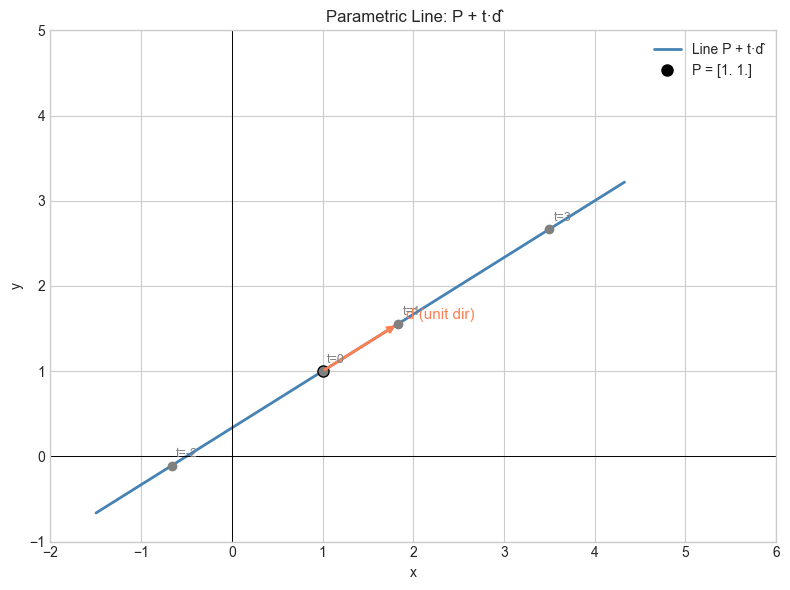

In [1]:
# --- Visualization: Parametric line using direction vector ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

P = np.array([1.0, 1.0])   # base point
v = np.array([3.0, 2.0])   # direction (unnormalized)
d = v / np.linalg.norm(v)  # unit direction

t_values = np.linspace(-3, 4, 100)
line_pts  = np.array([P + t * d for t in t_values])

# Specific points on the line
t_marks = [-2, 0, 1, 3]
marks   = [P + t * d for t in t_marks]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(line_pts[:, 0], line_pts[:, 1], 'steelblue', lw=2, label='Line P + t·d̂')
ax.plot(*P, 'ko', markersize=8, label=f'P = {P}')
ax.annotate('', xy=P+d, xytext=P,
            arrowprops=dict(arrowstyle='->', color='coral', lw=2))
ax.text(*(P+d*1.1), 'd̂ (unit dir)', color='coral', fontsize=11)

for m, t in zip(marks, t_marks):
    ax.plot(*m, 'o', color='gray', markersize=6)
    ax.text(m[0]+0.05, m[1]+0.1, f't={t}', fontsize=9, color='gray')

ax.set_xlim(-2, 6); ax.set_ylim(-1, 5)
ax.axhline(0, color='black', lw=0.7); ax.axvline(0, color='black', lw=0.7)
ax.set_title('Parametric Line: P + t·d̂')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Unit vector:** $\hat{\mathbf{v}} = \frac{\mathbf{v}}{\|\mathbf{v}\|}$ for any non-zero **v**. $\|\hat{\mathbf{v}}\|_2 = 1$.

**Standard basis vectors:** In ℝⁿ, $\mathbf{e}_i$ is the vector with 1 in position $i$, 0 elsewhere. These are the canonical unit direction vectors.

**Parametric line:** Given point $\mathbf{p}$ and direction $\hat{\mathbf{d}}$:

$$\ell(t) = \mathbf{p} + t\hat{\mathbf{d}}, \qquad t \in \mathbb{R}$$

At $t=0$: the point $\mathbf{p}$. At $t=1$: one unit step from $\mathbf{p}$ in direction $\hat{\mathbf{d}}$.

In [2]:
# --- Implementation: unit direction and parametric line ---
import numpy as np

def unit_vector(v):
    """Return unit vector in direction of v."""
    v = np.asarray(v, float)
    mag = np.linalg.norm(v)
    if mag < 1e-12:
        raise ValueError("Cannot normalize zero vector.")
    return v / mag


def parametric_line(p, direction, t_values):
    """
    Compute points on line p + t*direction.

    Args:
        p: ndarray shape (n,) — base point
        direction: ndarray shape (n,) — direction (need not be unit)
        t_values: array-like of scalars

    Returns:
        ndarray shape (len(t_values), n)
    """
    p = np.asarray(p, float)
    d = unit_vector(direction)
    return np.array([p + t * d for t in t_values])


# Standard basis in 3D
e1 = np.array([1.0, 0.0, 0.0])
e2 = np.array([0.0, 1.0, 0.0])
e3 = np.array([0.0, 0.0, 1.0])

for i, e in enumerate([e1, e2, e3], 1):
    print(f"e{i}: norm={np.linalg.norm(e):.1f}  direction={e}")

# Line from (2,1) in direction (3,2)
pts = parametric_line([2,1], [3,2], [-1, 0, 1, 2])
print("\nParametric line at t = -1, 0, 1, 2:")
for t, pt in zip([-1,0,1,2], pts):
    print(f"  t={t}: {pt}")

e1: norm=1.0  direction=[1. 0. 0.]
e2: norm=1.0  direction=[0. 1. 0.]
e3: norm=1.0  direction=[0. 0. 1.]

Parametric line at t = -1, 0, 1, 2:
  t=-1: [1.16794971 0.4452998 ]
  t=0: [2. 1.]
  t=1: [2.83205029 1.5547002 ]
  t=2: [3.66410059 2.10940039]


## 5. Experiments

In [3]:
# --- Experiment: Two direction vectors are the same iff they are equal (or negatives) ---
# Hypothesis: scaling a vector does not change its direction.
# Try changing: the scale factor.
import numpy as np

v = np.array([3.0, 4.0])
SCALE = 7.5  # <-- modify: try negative values too

scaled = SCALE * v
unit_v = v / np.linalg.norm(v)
unit_s = scaled / np.linalg.norm(scaled)

print(f"v = {v}")
print(f"scale * v = {scaled}")
print(f"unit(v) = {unit_v}")
print(f"unit(scale*v) = {unit_s}")
print(f"Same direction? {np.allclose(unit_v, unit_s)}")
print(f"Opposite direction? {np.allclose(unit_v, -unit_s)}")

v = [3. 4.]
scale * v = [22.5 30. ]
unit(v) = [0.6 0.8]
unit(scale*v) = [0.6 0.8]
Same direction? True
Opposite direction? False


## 6. Exercises

**Easy 1.** Find the unit vector in the direction of **v** = (5, 12). *(Expected: (5/13, 12/13))*

**Easy 2.** Write the parametric equation of the line through P = (2, 3) in direction **d** = (1, −1). What point is at t = 5?

**Medium 1.** Find the point on the line P + t**d** that is closest to the origin. *(Hint: minimize $\|P + t\mathbf{d}\|^2$ over t — connect to ch131 Dot Product)*

**Hard.** Two lines: $\ell_1(t) = P_1 + t\mathbf{d}_1$ and $\ell_2(s) = P_2 + s\mathbf{d}_2$. Find the values of t and s where the two lines are closest. *(Connects to ch134 — Projections)*

---

## 7. Summary & Connections

- A direction vector (unit vector) encodes orientation with magnitude 1.
- Any non-zero **v** decomposes as $\mathbf{v} = \|\mathbf{v}\| \cdot \hat{\mathbf{v}}$.
- Parametric lines: $\ell(t) = \mathbf{p} + t\hat{\mathbf{d}}$ — point + scalar × direction.

**Backward connection:** This formalizes the polar representation angle from ch124 — a direction vector at angle $\theta$ is $[\cos\theta, \sin\theta]$.

**Forward connections:**
- This will reappear in ch134 — Projections, where we project a vector onto a direction vector to find its component along that direction.
- This will reappear in ch143 — Vector Transformations, where directions are rotated and reflected.
- This will reappear in ch166 — Matrix Transformations Visualization, where matrix-vector products transform direction vectors.